In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchsummary import summary

import os
import re
import math
import numpy as np
import pandas as pd
import random
import collections
import json
import shutil
import zipfile
import copy
from datetime import datetime

import matplotlib.pyplot as plt
import sentencepiece as spm
from tqdm.auto import tqdm

from bert import BERT

random_seed = 1234
random.seed(random_seed)
np.random.seed(random_seed)

# torch version
print(torch.__version__)

2.7.1+cu126


- 데이터 확인

In [2]:
corpus_file = './data/kowiki.txt'

f = open(corpus_file, 'r')
lines = f.readlines()

print("=" * 100)
for idx, line in enumerate(lines):
    print(line.strip(), end="\n\n")
    if idx == 5: break;
f.close()
print("=" * 100)
print(f"Line Num: {len(lines):,}")

지미 카터

제임스 얼 "지미" 카터 주니어(, 1924년 10월 1일 ~ )는 민주당 출신 미국 39번째 대통령 (1977년 ~ 1981년)이다.

지미 카터는 조지아주 섬터 카운티 플레인스 마을에서 태어났다. 조지아 공과대학교를 졸업하였다. 그 후 해군에 들어가 전함·원자력·잠수함의 승무원으로 일하였다. 1953년 미국 해군 대위로 예편하였고 이후 땅콩·면화 등을 가꿔 많은 돈을 벌었다. 그의 별명이 "땅콩 농부" (Peanut Farmer)로 알려졌다.

1962년 조지아 주 상원 의원 선거에서 낙선하나 그 선거가 부정선거 였음을 입증하게 되어 당선되고, 1966년 조지아 주 지사 선거에 낙선하지만 1970년 조지아 주 지사를 역임했다. 대통령이 되기 전 조지아주 상원의원을 두번 연임했으며, 1971년부터 1975년까지 조지아 지사로 근무했다. 조지아 주지사로 지내면서, 미국에 사는 흑인 등용법을 내세웠다.

1976년 대통령 선거에 민주당 후보로 출마하여 도덕주의 정책으로 내세워, 포드를 누르고 당선되었다.

카터 대통령은 에너지 개발을 촉구했으나 공화당의 반대로 무산되었다.

Line Num: 3,957,761


In [3]:
corpus_file = './data/kowiki.txt'
prefix = './models/ko_8000'

# vocab_size = 8000
# spm.SentencePieceTrainer.train(
#     input=corpus_file,
#     model_prefix=prefix,
#     vocab_size=vocab_size + 7,
#     model_type='bpe',
#     max_sentence_length=999999,
#     pad_id=0, pad_piece='[PAD]',
#     unk_id=1, unk_piece='[UNK]',
#     bos_id=2, bos_piece='[BOS]',
#     eos_id=3, eos_piece='[EOS]',
#     user_defined_symbols='[SEP],[CLS],[MASK]'
# )

In [4]:
model_dir = './models/ko_8000.model'

# vocab loading
vocab = spm.SentencePieceProcessor()
vocab.load(model_dir)

True

- MASK 생성 함수

In [5]:
# Q. 위 코드들을 참고하여 아래 함수를 완성시켜주세요.
def create_pretrain_mask(tokens, mask_cnt, vocab_list):
    """
    마스크 생성
    :param tokens: tokens
    :param mask_cnt: mask 개수 (전체 tokens의 15%)
    :param vocab_list: vocab list (random token 용)
    :return tokens: mask된 tokens
    :return mask_idx: mask된 token의 index
    :return mask_label: mask된 token의 원래 값
    """
    # 단어 단위로 mask 하기 위해서 index 분할 (띄어쓰기)
    cand_idx = []
    for (i, token) in enumerate(tokens):
        if token == "[CLS]" or token == "[SEP]":
            continue
        if 0 < len(cand_idx) and not token.startswith(u"\u2581"):
            cand_idx[-1].append(i)
        else:
            cand_idx.append([i])

    # random mask를 위해서 순서를 섞음 (shuffle)
    random.shuffle(cand_idx)
    mask_lms = []
    for index_set in cand_idx:
        if len(mask_lms) >= mask_cnt:
            break
        if len(mask_lms) + len(index_set) > mask_cnt:
            continue
        dice = random.random()
        for index in index_set:
            masked_token = None
            if dice < 0.8:
                masked_token = "[MASK]"
            elif dice < 0.9:
                masked_token = tokens[index]
            else:
                masked_token = random.choice(vocab_list)
            mask_lms.append({"index": index, "label": tokens[index]})
            tokens[index] = masked_token

    # mask_lms 정렬 후 mask_idx, mask_label 추출 (sorted 사용)
    mask_lms = sorted(mask_lms, key=lambda x: x["index"])
    mask_idx = [p["index"] for p in mask_lms]
    mask_label = [p["label"] for p in mask_lms]

    return tokens, mask_idx, mask_label

- NSP pair 생성 함수

In [6]:
def trim_tokens(tokens_a, tokens_b, max_seq):
    """
    tokens_a, tokens_b의 길이를 줄임 최대 길이: max_seq
    :param tokens_a: tokens A
    :param tokens_b: tokens B
    :param max_seq: 두 tokens 길이의 최대 값
    """
    while True:
        total_length = len(tokens_a) + len(tokens_b)
        if total_length <= max_seq:
            break

        if len(tokens_a) > len(tokens_b):
            del tokens_a[0]
        else:
            tokens_b.pop()

def create_pretrain_instances(vocab, doc, n_seq, mask_prob, vocab_list):
    """
    doc별 pretrain 데이터 생성
    """
    # for [CLS], [SEP], [SEP]
    max_seq = n_seq - 3

    instances = []
    current_chunk = []
    current_length = 0
    for i in range(len(doc)):
        current_chunk.append(doc[i])  # line
        current_length += len(doc[i])
        if 1 < len(current_chunk) and (i == len(doc) - 1 or current_length >= max_seq):
            # token a
            a_end = 1
            if 1 < len(current_chunk):
                a_end = random.randrange(1, len(current_chunk))
            tokens_a = []
            for j in range(a_end):
                tokens_a.extend(current_chunk[j])
            # token b
            tokens_b = []
            for j in range(a_end, len(current_chunk)):
                tokens_b.extend(current_chunk[j])

            if random.random() < 0.5:  # 50% 확률로 swap
                is_next = 0
                tokens_t = tokens_a
                tokens_a = tokens_b
                tokens_b = tokens_t
            else:
                is_next = 1
            # max_seq 보다 큰 경우 길이 조절
            trim_tokens(tokens_a, tokens_b, max_seq)
            assert 0 < len(tokens_a)
            assert 0 < len(tokens_b)
            # tokens & aegment 생성
            tokens = ["[CLS]"] + tokens_a + ["[SEP]"] + tokens_b + ["[SEP]"]
            segment = [0] * (len(tokens_a) + 2) + [1] * (len(tokens_b) + 1)
            # mask
            tokens, mask_idx, mask_label = create_pretrain_mask(tokens, int((len(tokens) - 3) * mask_prob), vocab_list)

            instance = {
                "tokens": tokens,
                "segment": segment,
                "is_next": is_next,
                "mask_idx": mask_idx,
                "mask_label": mask_label
            }
            instances.append(instance)

            current_chunk = []
            current_length = 0
    return instances

- pretrain을 위한 데이터 생성

In [7]:
def make_pretrain_data(vocab, in_file, out_file, n_seq, mask_prob=0.15, count=None):
    """ pretrain 데이터 생성 """
    def save_pretrain_instances(out_f, doc):
        instances = create_pretrain_instances(vocab, doc, n_seq, mask_prob, vocab_list)
        for instance in instances:
            out_f.write(json.dumps(instance, ensure_ascii=False))
            out_f.write("\n")

    # 특수문자 7개를 제외한 vocab_list 생성
    vocab_list = []
    for id in range(7, len(vocab)):
        if not vocab.is_unknown(id):
            vocab_list.append(vocab.id_to_piece(id))

    # line count 확인
    line_cnt = 0
    with open(in_file, "r") as in_f:
        for line in in_f:
            line_cnt += 1

    instance_cnt = 0
    with open(in_file, "r") as in_f:
        with open(out_file, "w") as out_f:
            doc = []
            for line in tqdm(in_f, total=line_cnt):
                line = line.strip()
                if line == "":  # line이 빈줄 일 경우 (새로운 단락을 의미 함)
                    if 0 < len(doc):
                        save_pretrain_instances(out_f, doc)
                        doc = []
                else:  # line이 빈줄이 아닐 경우 tokenize 해서 doc에 저장
                    pieces = vocab.encode_as_pieces(line)
                    if 0 < len(pieces):
                        doc.append(pieces)

                if count is not None and instance_cnt >= count:
                    break

            if 0 < len(doc):  # 마지막에 처리되지 않은 doc가 있는 경우
                save_pretrain_instances(out_f, doc)
                doc = []

def make_pretrain_data(vocab, in_file, out_file, n_seq, mask_prob=0.15, count=None): # <--- 1. count 인자 추가
    """ pretrain 데이터 생성 """
    # Helper 함수 수정: 생성된 인스턴스 수를 세고, count에 도달하면 중단
    def save_pretrain_instances(out_f, doc, current_instance_cnt):
        instances = create_pretrain_instances(vocab, doc, n_seq, mask_prob, vocab_list)
        for instance in instances:
            # count가 지정되었고, 현재 인스턴스 수가 count를 넘어서면 더 이상 저장하지 않음
            if count is not None and current_instance_cnt >= count:
                break
            out_f.write(json.dumps(instance, ensure_ascii=False))
            out_f.write("\n")
            current_instance_cnt += 1
        return current_instance_cnt # <--- 2. 업데이트된 인스턴스 수 반환

    vocab_list = []
    for id in range(7, len(vocab)):
        if not vocab.is_unknown(id):
            vocab_list.append(vocab.id_to_piece(id))

    line_cnt = 0
    with open(in_file, "r") as in_f:
        for line in in_f:
            line_cnt += 1

    instance_cnt = 0 # <--- 3. 인스턴스 수를 셀 변수 초기화
    with open(in_file, "r") as in_f:
        with open(out_file, "w") as out_f:
            doc = []
            for line in tqdm(in_f, total=line_cnt):
                line = line.strip()
                if line == "":
                    if 0 < len(doc):
                        # 이전 인스턴스 수와 진행률 업데이트
                        prev_cnt = instance_cnt
                        instance_cnt = save_pretrain_instances(out_f, doc, instance_cnt)
                        doc = []
                else:
                    pieces = vocab.encode_as_pieces(line)
                    if 0 < len(pieces):
                        doc.append(pieces)

                # count에 도달하면 전체 루프 중단
                if count is not None and instance_cnt >= count:
                    break

            # 파일 끝까지 읽었지만 count에 도달하지 않은 경우, 남은 doc 처리
            if 0 < len(doc) and (count is None or instance_cnt < count):
                prev_cnt = instance_cnt
                instance_cnt = save_pretrain_instances(out_f, doc, instance_cnt)
                doc = []


In [8]:
pretrain_json_path = './data/bert_pre_train.json'

In [9]:
make_pretrain_data(vocab, corpus_file, pretrain_json_path, 128, count=150000)

total = 0
with open(pretrain_json_path, "r") as f:
    for line in f:
        total += 1

print("=" * 100)
print(f"Data Num: {total:,}")
print("=" * 100)

  0%|          | 0/3957761 [00:00<?, ?it/s]

Data Num: 150,000


- JSON형태로 저장된 데이터 로드

In [10]:
def load_pre_train_data(vocab, filename, n_seq, count=None):
    """
    학습에 필요한 데이터를 로드
    :param vocab: vocab
    :param filename: 전처리된 json 파일
    :param n_seq: 시퀀스 길이 (number of sequence)
    :param count: 데이터 수 제한 (None이면 전체)
    :return enc_tokens: encoder inputs
    :return segments: segment inputs
    :return labels_nsp: nsp labels
    :return labels_mlm: mlm labels
    """
    total = 0
    with open(filename, "r") as f:
        for line in f:
            total += 1
            # 데이터 수 제한
            if count is not None and count <= total:
                break

    # np.memmap을 사용하면 메모리를 적은 메모리에서도 대용량 데이터 처리가 가능 함
    enc_tokens = np.memmap(filename='enc_tokens.memmap', mode='w+', dtype=np.int32, shape=(total, n_seq))
    segments = np.memmap(filename='segments.memmap', mode='w+', dtype=np.int32, shape=(total, n_seq))
    labels_nsp = np.memmap(filename='labels_nsp.memmap', mode='w+', dtype=np.int32, shape=(total,))
    labels_mlm = np.memmap(filename='labels_mlm.memmap', mode='w+', dtype=np.int32, shape=(total, n_seq))

    with open(filename, "r") as f:
        for i, line in enumerate(tqdm(f, total=total)):
            if total <= i:
                print("data load early stop", total, i)
                break
            data = json.loads(line)
            # encoder token
            enc_token = [vocab.piece_to_id(p) for p in data["tokens"]]
            enc_token += [0] * (n_seq - len(enc_token))
            # segment
            segment = data["segment"]
            segment += [0] * (n_seq - len(segment))
            # nsp label
            label_nsp = data["is_next"]
            # mlm label
            mask_idx = np.array(data["mask_idx"], dtype=np.int32)
            mask_label = np.array([vocab.piece_to_id(p) for p in data["mask_label"]], dtype=np.int32)
            label_mlm = np.full(n_seq, dtype=np.int32, fill_value=0)
            label_mlm[mask_idx] = mask_label

            assert len(enc_token) == len(segment) == len(label_mlm) == n_seq

            enc_tokens[i] = enc_token
            segments[i] = segment
            labels_nsp[i] = label_nsp
            labels_mlm[i] = label_mlm

    return (enc_tokens, segments), (labels_nsp, labels_mlm)


pre_train_inputs, pre_train_labels = load_pre_train_data(vocab, pretrain_json_path, 128, count=150000)

  0%|          | 0/150000 [00:00<?, ?it/s]

- Train/Test Split

In [11]:
test_input = (pre_train_inputs[0][:500], pre_train_inputs[1][:500])
test_label = (pre_train_labels[0][:500], pre_train_labels[1][:500])

pre_train_inputs = (pre_train_inputs[0][500:], pre_train_inputs[1][500:])
pre_train_labels = (pre_train_labels[0][500:], pre_train_labels[1][500:])

- 모델 정의

In [12]:
class PooledOutput(nn.Module):
    def __init__(self, config, n_output, name="pooled_output"):
        super(PooledOutput, self).__init__()

        self.dense1 = nn.Linear(config.d_model, config.d_model)
        self.dense2 = nn.Linear(config.d_model, n_output, bias=False)

    def forward(self, inputs):
        """
        forward pass
        :param inputs: 모델의 출력 (예: logits_cls)
        :return: softmax된 결과
        """
        outputs = F.tanh(self.dense1(inputs))
        outputs = self.dense2(outputs)
        # outputs = F.softmax(outputs, dim=-1)
        return outputs

class PreTrainModel(nn.Module):
    def __init__(self, config):
        super(PreTrainModel, self).__init__()
        self.bert = BERT(config)
        self.pooled_output = PooledOutput(config, 2)

    def forward(self, enc_tokens, segments):
        enc_tokens = enc_tokens.long()
        segments = segments.long()

        logits_cls, logits_lm = self.bert(enc_tokens, segments)

        logits_nsp = self.pooled_output(logits_cls)
        # outputs_nsp = F.softmax(logits_cls, dim=-1)
        #
        # outputs_mlm = F.softmax(logits_lm, dim=-1)
        return logits_nsp, logits_lm

def build_model_pre_train(config):
    return PreTrainModel(config)

class Config:
    def __init__(self, config_dict):
        for key, value in config_dict.items():
            setattr(self, key, value)

config = Config({
    "d_model": 512,
    "n_head": 8,
    "d_head": 128,
    "dropout": 0.1,
    "d_ff": 1024,
    "layernorm_epsilon": 0.001,
    "n_layer": 4,
    "n_seq": 256,
    "n_vocab": 8000,
    "i_pad": 0
})

class Vocab:
    def __init__(self, vocab_size):
        self.vocab_size = vocab_size
        self.pad_id = 0

vocab = Vocab(config.n_vocab)
config.n_vocab = vocab.vocab_size
config.i_pad = vocab.pad_id


In [13]:
def lm_loss(y_true, y_pred):
    """
    loss 계산 함수
    :param y_true: 정답 (bs, n_seq)
    :param y_pred: 예측 값 (bs, n_seq, n_vocab)
    """
    # loss 계산
    loss = F.cross_entropy(y_pred.view(-1, y_pred.size(-1)), y_true.view(-1), reduction='none')
    # pad(0) 인 부분 mask
    mask = (y_true != 0).float()
    loss = loss * mask
    return loss.mean() * 20   # mlm을 더 잘 학습하도록 20배 증가 시킴

def lm_acc(y_true, y_pred):
    """
    acc 계산 함수
    :param y_true: 정답 (bs, n_seq)
    :param y_pred: 예측 값 (bs, n_seq, n_vocab)
    """
    # 정답 여부 확인
    y_pred_class = torch.argmax(y_pred, dim=-1).float()
    matches = (y_true == y_pred_class).float()
    # pad(0) 인 부분 mask
    mask = (y_true != 0).float()
    matches *= mask
    # 정확도 계산
    accuracy = matches.sum() / mask.sum().clamp(min=1)
    return accuracy

In [14]:
# 모델 생성
from torchinfo import summary

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

config.n_seq = 128
pre_train_model = build_model_pre_train(config)
pre_train_model.to(device)

print(pre_train_model)

device: cuda
PreTrainModel(
  (bert): BERT(
    (embedding): SharedEmbedding()
    (position): PositionEmbedding(
      (embedding): Embedding(128, 512)
    )
    (segment): Embedding(2, 512)
    (norm): LayerNorm((512,), eps=0.001, elementwise_affine=True)
    (encoder_layers): ModuleList(
      (0-3): 4 x EncoderLayer(
        (self_attention): MultiHeadAttention(
          (W_Q): Linear(in_features=512, out_features=1024, bias=True)
          (W_K): Linear(in_features=512, out_features=1024, bias=True)
          (W_V): Linear(in_features=512, out_features=1024, bias=True)
          (attention): ScaleDotProductAttention()
          (W_O): Linear(in_features=1024, out_features=512, bias=True)
        )
        (norm1): LayerNorm((512,), eps=0.001, elementwise_affine=True)
        (ffn): PositionWiseFeedForward(
          (W_1): Linear(in_features=512, out_features=1024, bias=True)
          (W_2): Linear(in_features=1024, out_features=512, bias=True)
          (gelu): GELU(approximate

In [15]:
enc_tokens_example = torch.randint(0, config.n_vocab, (10, config.n_seq), dtype=torch.long).to(device)
segments_example = torch.randint(0, 2, (10, config.n_seq), dtype=torch.long).to(device)

summary(pre_train_model, [(10, config.n_seq), (10, config.n_seq)])

Layer (type:depth-idx)                                       Output Shape              Param #
PreTrainModel                                                [10, 2]                   --
├─BERT: 1-1                                                  [10, 512]                 --
│    └─SharedEmbedding: 2-1                                  [10, 128, 512]            4,096,000
│    └─PositionEmbedding: 2-2                                [10, 128, 512]            --
│    │    └─Embedding: 3-1                                   [10, 128, 512]            65,536
│    └─Embedding: 2-3                                        [10, 128, 512]            1,024
│    └─LayerNorm: 2-4                                        [10, 128, 512]            1,024
│    └─Dropout: 2-5                                          [10, 128, 512]            --
│    └─ModuleList: 2-6                                       --                        --
│    │    └─EncoderLayer: 3-2                                [10, 128, 512]   

In [16]:
epochs = 20
batch_size = 512

train_steps = math.ceil(len(pre_train_inputs[0]) / batch_size) * epochs
print("train_steps:", train_steps)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # GPU가 있으면 cuda 사용, 없으면 CPU
print("device:", device)

optimizer = optim.Adam(pre_train_model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=train_steps, eta_min=1e-5)
# scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=1, eta_min=1e-5)

loss_fn_nsp = nn.CrossEntropyLoss()
loss_fn_mlm = nn.CrossEntropyLoss()

train_steps: 5840
device: cuda


In [17]:
pre_train_inputs = [torch.tensor(np.array(x)) for x in pre_train_inputs]
pre_train_labels = [torch.tensor(np.array(x)) for x in pre_train_labels]

In [18]:
pre_test_inputs = [torch.tensor(np.array(x)) for x in test_input]
pre_test_labels = [torch.tensor(np.array(x)) for x in test_label]

In [19]:
train_dataset = TensorDataset(pre_train_inputs[0], pre_train_inputs[1], pre_train_labels[0], pre_train_labels[1])
train_dataloader = DataLoader(
    train_dataset, batch_size=batch_size, shuffle=True,
    pin_memory=True,
    drop_last=True,
)

test_dataset = TensorDataset(pre_test_inputs[0], pre_test_inputs[1], pre_test_labels[0], pre_test_labels[1])
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [20]:
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print("VRAM cache cleared.")

VRAM cache cleared.


In [21]:
history = {
    'nsp_loss_train': [],
    'mlm_loss_train': [],
    'nsp_acc_train': [],
    'mlm_acc_train': []
}

use_amp = True
if use_amp:
    scaler = torch.amp.GradScaler()

for epoch in range(epochs):
    pre_train_model.train()
    total_loss = 0
    total_nsp_loss = 0
    total_mlm_loss = 0
    total_nsp_acc = 0
    total_mlm_acc = 0

    t_bar = tqdm(train_dataloader, leave=False, dynamic_ncols=True, desc=f"Epoch {epoch+1}/{epochs}")
    for batch in t_bar:
        enc_tokens_batch, segments_batch, labels_nsp_batch, labels_mlm_batch = batch
        enc_tokens_batch = enc_tokens_batch.to(device)
        segments_batch = segments_batch.to(device)
        labels_nsp_batch = labels_nsp_batch.to(device)
        labels_mlm_batch = labels_mlm_batch.to(device)

        optimizer.zero_grad()

        if use_amp:
            with torch.amp.autocast(dtype=torch.bfloat16, device_type="cuda"):
                logits_nsp, logits_mlm = pre_train_model(enc_tokens_batch, segments_batch)

                labels_nsp_batch = labels_nsp_batch.long()
                labels_mlm_batch = labels_mlm_batch.clamp(0, config.n_vocab - 1).long()

                loss_nsp = loss_fn_nsp(logits_nsp, labels_nsp_batch)
                loss_mlm = loss_fn_mlm(logits_mlm.view(-1, logits_mlm.shape[-1]), labels_mlm_batch.view(-1))

                total_loss_batch = loss_nsp + loss_mlm

            scaler.scale(total_loss_batch).backward()
            scaler.step(optimizer)
            scaler.update()

        else:
            logits_nsp, logits_mlm = pre_train_model(enc_tokens_batch, segments_batch)

            labels_nsp_batch = labels_nsp_batch.long()
            labels_mlm_batch = labels_mlm_batch.clamp(0, config.n_vocab - 1).long()

            loss_nsp = loss_fn_nsp(logits_nsp, labels_nsp_batch)
            loss_mlm = loss_fn_mlm(logits_mlm.view(-1, logits_mlm.shape[-1]), labels_mlm_batch.view(-1))

            total_loss_batch = loss_nsp + loss_mlm
            total_loss_batch.backward()
            optimizer.step()

        scheduler.step()
        current_lr = scheduler.get_last_lr()[0]
        t_bar.set_postfix(lr=current_lr, refresh=True)

        total_loss += total_loss_batch.item()
        total_nsp_loss += loss_nsp.item()
        total_mlm_loss += loss_mlm.item()

        nsp_acc = (logits_nsp.argmax(dim=-1) == labels_nsp_batch).float().mean()
        mlm_acc = (logits_mlm.argmax(dim=-1) == labels_mlm_batch).float().mean()

        total_nsp_acc += nsp_acc.item()
        total_mlm_acc += mlm_acc.item()


    # 결과 저장
    nsp_loss_train = total_nsp_loss / len(train_dataloader)
    mlm_loss_train = total_mlm_loss / len(train_dataloader)
    nsp_acc_train = total_nsp_acc / len(train_dataloader)
    mlm_acc_train = total_mlm_acc / len(train_dataloader)

    history['nsp_loss_train'].append(nsp_loss_train)
    history['mlm_loss_train'].append(mlm_loss_train)
    history['nsp_acc_train'].append(nsp_acc_train)
    history['mlm_acc_train'].append(mlm_acc_train)

    avg_train_loss = total_loss / len(train_dataloader)

    print(f"[Epoch {epoch+1}] Train Loss {avg_train_loss:.4f} NSP Loss: {nsp_loss_train:.4f} MLM Loss: {mlm_loss_train:.4f} "
          f"NSP Accuracy: {nsp_acc_train:.4f}, MLM Accuracy: {mlm_acc_train:.4f}")

    # 모델 저장
    # torch.save(pre_train_model.state_dict(), f"./bert_pre_train_epoch_{epoch+1}.pt")


Epoch 1/20:   0%|          | 0/291 [00:00<?, ?it/s]

[Epoch 1] Train Loss 2.1158 NSP Loss: 0.7131 MLM Loss: 1.4027 NSP Accuracy: 0.4992, MLM Accuracy: 0.8664


Epoch 2/20:   0%|          | 0/291 [00:00<?, ?it/s]

[Epoch 2] Train Loss 2.0585 NSP Loss: 0.6946 MLM Loss: 1.3639 NSP Accuracy: 0.4989, MLM Accuracy: 0.8693


Epoch 3/20:   0%|          | 0/291 [00:00<?, ?it/s]

...

[Epoch 18] Train Loss 2.0445 NSP Loss: 0.6928 MLM Loss: 1.3517 NSP Accuracy: 0.5011, MLM Accuracy: 0.8693


Epoch 19/20:   0%|          | 0/291 [00:00<?, ?it/s]

[Epoch 19] Train Loss 2.0440 NSP Loss: 0.6925 MLM Loss: 1.3515 NSP Accuracy: 0.5005, MLM Accuracy: 0.8693


Epoch 20/20:   0%|          | 0/291 [00:00<?, ?it/s]

[Epoch 20] Train Loss 2.0437 NSP Loss: 0.6924 MLM Loss: 1.3512 NSP Accuracy: 0.4987, MLM Accuracy: 0.8694


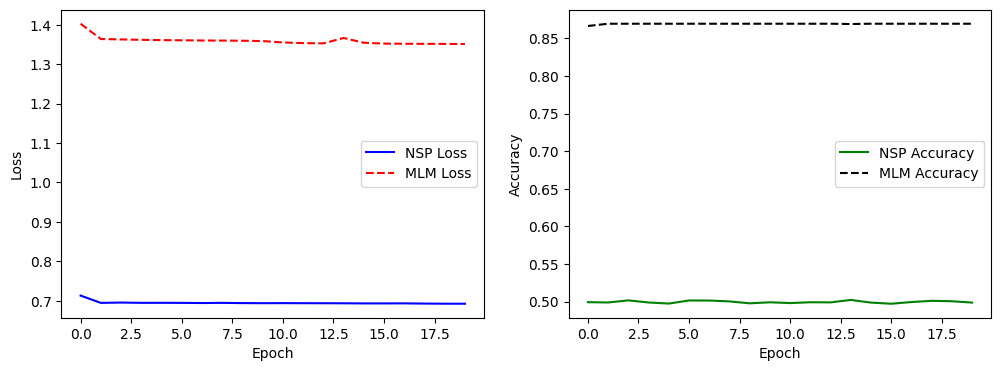

In [23]:
import matplotlib.pyplot as plt

# training result
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history['nsp_loss_train'], 'b-', label='NSP Loss')
plt.plot(history['mlm_loss_train'], 'r--', label='MLM Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['nsp_acc_train'], 'g-', label='NSP Accuracy')
plt.plot(history['mlm_acc_train'], 'k--', label='MLM Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [26]:
def evaluate(model, dataloader, device):
    model.eval()

    total_nsp_acc = 0
    total_mlm_acc = 0
    with torch.no_grad():
        for batch in dataloader:
            enc_tokens_batch, segments_batch, labels_nsp_batch, labels_mlm_batch = batch

            # 데이터를 device로 이동
            enc_tokens_batch = enc_tokens_batch.to(device)
            segments_batch = segments_batch.to(device)
            labels_nsp_batch = labels_nsp_batch.to(device)
            labels_mlm_batch = labels_mlm_batch.to(device)

            # 모델 Forward Pass
            logits_nsp, logits_mlm = model(enc_tokens_batch, segments_batch)

            nsp_acc = (logits_nsp.argmax(dim=-1) == labels_nsp_batch).float().mean()
            mlm_acc = (logits_mlm.argmax(dim=-1) == labels_mlm_batch).float().mean()

            total_nsp_acc += nsp_acc.item()
            total_mlm_acc += mlm_acc.item()

    avg_nsp_acc = total_nsp_acc / len(dataloader)
    avg_mlm_acc = total_mlm_acc / len(dataloader)

    return avg_nsp_acc, avg_mlm_acc


test_nsp_acc, test_mlm_acc = evaluate(pre_train_model, test_dataloader, device)

print(f"\n[Test Results]")
print(f"NSP Accuracy: {test_nsp_acc:.4f}")
print(f"MLM Accuracy: {test_mlm_acc:.4f}")
print("="*50)


[Test Results]
NSP Accuracy: 0.5000
MLM Accuracy: 0.8637


- 모델의 forward와 Pooled output 모두에 softmax가 있어서 처음에는 loss가 한번 감소하고 쭉 감소하지 않았다.
- forward, pooled output 둘 다 softmax 제거 후 loss가 감소하는 것을 확인
- loss는 꾸준히 감소하지만 acc는 개선되지 않는다.